# Examen Práctico — Primer Parcial
## Tópicos de Big Data

**Instrucciones generales**

- Este notebook es tu entregable. Complétalo en orden, sin borrar los enunciados.
- Al final debes subir este archivo (`.ipynb`) al repositorio de GitHub del curso, en la carpeta correspondiente a tu nombre/usuario.
- Se evaluará tanto el código (que corra sin errores, de arriba hacia abajo) como tus interpretaciones escritas en las celdas de texto marcadas como *"Interpretación"*.
- Cada quien trabaja con **un dataset distinto**, asignado por la profesora. No copies celdas de un compañero con un dataset diferente: aunque las preguntas se parecen, los datos y las columnas no son las mismas.



## 0. Datos del alumno

Completa la siguiente celda con tus datos y el nombre del dataset que te fue asignado.

In [1]:
# --- COMPLETA CON TUS DATOS ---
NOMBRE = "Diego Gael Tierra"            # Tu nombre completo
MATRICULA = "COMPLETAR"         # Tu matrícula o número de cuenta
DATASET_ASIGNADO = "alcohol"  # Debe ser uno de: "alcohol", "migracion", "desnutricion", "pib", "homicidios"

print(f"Alumno: {NOMBRE}")
print(f"Matrícula: {MATRICULA}")
print(f"Dataset asignado: {DATASET_ASIGNADO}")


Alumno: Diego Gael Tierra
Matrícula: COMPLETAR
Dataset asignado: alcohol


## 1. Configuración del entorno virtual (Visual Studio Code)

Antes de instalar librerías directamente en tu sistema, es una buena práctica crear un
**entorno virtual** exclusivo para este examen. Esto evita conflictos de versiones con
otros proyectos y hace que tu entorno de trabajo sea reproducible.

**Requisitos previos en VS Code:** ten instaladas las extensiones oficiales **"Python"**
y **"Jupyter"** (ambas de Microsoft), disponibles en la pestaña de Extensiones (ícono de
cuadritos en la barra lateral izquierda, o `Ctrl+Shift+X` / `Cmd+Shift+X`).

Abre una terminal **dentro de VS Code** (menú **Terminal → New Terminal**, o
`` Ctrl+ñ ``/`` Ctrl+` ``) y verifica que estés ubicado en la carpeta de tu repositorio
del curso (donde vas a guardar este notebook).

### Windows (PowerShell, terminal integrada de VS Code)

```powershell
# 1. Crear el entorno virtual (se creará una carpeta llamada ".venv")
python -m venv .venv

# 2. Activar el entorno virtual
.venv\Scripts\Activate.ps1

# Si PowerShell bloquea la ejecución de scripts, ejecuta una sola vez:
#   Set-ExecutionPolicy -Scope CurrentUser RemoteSigned
# y vuelve a intentar activar el entorno.

# 3. Instalar las librerías necesarias
pip install pandas numpy ipykernel matplotlib requests
```

### macOS / Linux (terminal integrada de VS Code, bash o zsh)

```bash
# 1. Crear el entorno virtual (se creará una carpeta llamada ".venv")
python3 -m venv .venv

# 2. Activar el entorno virtual
source .venv/bin/activate

# 3. Instalar las librerías necesarias
pip install pandas numpy ipykernel matplotlib requests
```

> **Nota:** usamos el nombre `.venv` (con punto) porque VS Code lo detecta automáticamente
> dentro de la carpeta del proyecto. Si usas Anaconda/Miniconda en lugar de `venv`, el
> equivalente es:
> ```bash
> conda create -n examen-bigdata python=3.11 pandas numpy ipykernel matplotlib requests -y
> conda activate examen-bigdata
> ```

### Seleccionar el entorno virtual como kernel en VS Code

A diferencia de Jupyter Notebook/Lab, en VS Code **no necesitas registrar el entorno
manualmente con `ipykernel install`**: basta con tener el paquete `ipykernel` instalado
en el entorno (ya quedó instalado en el paso anterior) y seleccionar ese entorno
directamente como kernel del notebook.

1. Abre este archivo `.ipynb` en VS Code.
2. En la esquina superior derecha del notebook, haz clic en el selector de kernel
   (dice algo como **"Select Kernel"** la primera vez).
3. Elige **"Python Environments..."** y de la lista selecciona el entorno `.venv`
   que acabas de crear (debe aparecer como algo como `.venv (Python 3.x.x)` con la
   ruta de tu proyecto).
4. Si no aparece en la lista, haz clic en **"Select Another Kernel" → "Python
   Environments..."** y usa **"Enter interpreter path..."** para localizar manualmente
   el ejecutable dentro de `.venv/bin/python` (macOS/Linux) o `.venv\Scripts\python.exe`
   (Windows).
5. Verifica que quedó bien seleccionado ejecutando la celda de abajo: debe mostrar una
   ruta que contenga la carpeta `.venv` (o el nombre de tu entorno de conda), y no la
   instalación global de Python.

In [2]:
import sys
print(sys.executable)
# Debe mostrar una ruta dentro de tu carpeta "venv" (o de tu entorno "examen-bigdata" si usas conda).
# Si muestra la ruta de tu instalacion global de Python, regresa al paso anterior
# y selecciona el kernel correcto antes de continuar.


D:\big data\primera\.venv\Scripts\python.exe


## 2. Configuración y carga de datos

La siguiente celda **no se modifica**. Contiene la configuración de los 5 datasets
posibles del examen. A partir de tu variable `DATASET_ASIGNADO` de la celda anterior,
el notebook cargará automáticamente el dataset y los metadatos que te corresponden.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import requests

# --- NO MODIFICAR: configuración de los 5 datasets del examen ---
DATASETS = {
    "alcohol": {
        "csv": "https://ourworldindata.org/grapher/share-of-adults-who-drank-alcohol-in-last-year.csv?v=1&csvType=full&useColumnShortNames=true",
        "meta": "https://ourworldindata.org/grapher/share-of-adults-who-drank-alcohol-in-last-year.metadata.json?v=1&csvType=full&useColumnShortNames=true",
        "valor_col": "alcohol__consumers_past_12_months__pct__age_standardized__sex_both_sexes",
        "filtro_paises": "code",       # columna a usar para filtrar países reales vs. agregados
        "descripcion": "Porcentaje de adultos (15+) que bebieron alcohol en el ultimo anio",
        "unidad": "%",
    },
    "migracion": {
        "csv": "https://ourworldindata.org/grapher/migrant-populations.csv?v=1&csvType=full&useColumnShortNames=true&metric=immigrants&unit=number",
        "meta": "https://ourworldindata.org/grapher/migrant-populations.metadata.json?v=1&csvType=full&useColumnShortNames=true&metric=immigrants&unit=number",
        "valor_col": "immigrants_all",
        "filtro_paises": "owid_region",
        "descripcion": "Numero total de inmigrantes internacionales residiendo en el pais",
        "unidad": "personas",
    },
    "desnutricion": {
        "csv": "https://ourworldindata.org/grapher/number-undernourished.csv?v=1&csvType=full&useColumnShortNames=true",
        "meta": "https://ourworldindata.org/grapher/number-undernourished.metadata.json?v=1&csvType=full&useColumnShortNames=true",
        "valor_col": "_2_1_1_number_of_undernourished_people__000000000024001__value__006132__millions",
        "filtro_paises": "code",
        "descripcion": "Numero de personas subalimentadas (desnutricion)",
        "unidad": "personas",
    },
    "pib": {
        "csv": "https://ourworldindata.org/grapher/gdp-per-capita-worldbank-constant-usd.csv?v=1&csvType=full&useColumnShortNames=true",
        "meta": "https://ourworldindata.org/grapher/gdp-per-capita-worldbank-constant-usd.metadata.json?v=1&csvType=full&useColumnShortNames=true",
        "valor_col": "ny_gdp_pcap_kd",
        "filtro_paises": "code",
        "descripcion": "PIB per capita (dolares constantes de 2015)",
        "unidad": "USD",
    },
    "homicidios": {
        "csv": "https://ourworldindata.org/grapher/homicides-unodc.csv?v=1&csvType=full&useColumnShortNames=true",
        "meta": "https://ourworldindata.org/grapher/homicides-unodc.metadata.json?v=1&csvType=full&useColumnShortNames=true",
        "valor_col": "value__category_total__sex_total__age_total__unit_of_measurement_counts",
        "filtro_paises": "owid_region",
        "descripcion": "Numero de homicidios intencionales por anio",
        "unidad": "homicidios",
    },
}

assert DATASET_ASIGNADO in DATASETS, (
    "DATASET_ASIGNADO debe ser uno de: " + ", ".join(DATASETS.keys())
)

config = DATASETS[DATASET_ASIGNADO]
print(f"Cargando dataset: {DATASET_ASIGNADO}")
print(f"Descripcion: {config['descripcion']} ({config['unidad']})")


Cargando dataset: alcohol
Descripcion: Porcentaje de adultos (15+) que bebieron alcohol en el ultimo anio (%)


In [4]:
# Carga de datos y metadatos desde Our World in Data
df = pd.read_csv(
    config["csv"],
    storage_options={'User-Agent': 'Our World In Data data fetch/1.0'}
)
metadata = requests.get(config["meta"]).json()

# Renombramos la columna de valor a "valor" para trabajar mas comodo durante todo el notebook
df = df.rename(columns={config["valor_col"]: "valor"})


In [5]:
df.head(25)

,entity,code,year,valor
0,Afghanistan,AFG,2000,2.034725
1,Afghanistan,AFG,2001,2.032329
2,Afghanistan,AFG,2002,2.033833
3,Afghanistan,AFG,2003,2.034417
4,Afghanistan,AFG,2004,2.035337
5,Afghanistan,AFG,2005,2.034475
6,Afghanistan,AFG,2006,2.038559
7,Afghanistan,AFG,2007,2.029229
8,Afghanistan,AFG,2008,2.022360
9,Afghanistan,AFG,2009,2.018910


## 3. Exploración inicial

Antes de responder las preguntas de análisis, explora el dataset: tipos de datos,
dimensiones, valores nulos y estadísticas descriptivas básicas.

In [6]:
# Forma del dataset (filas, columnas)
df.shape


(3929, 4)

In [7]:
# Tipos de datos e informacion general
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 3929 entries, 0 to 3928
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   entity  3929 non-null   str    
 1   code    3929 non-null   str    
 2   year    3929 non-null   int64  
 3   valor   3929 non-null   float64
dtypes: float64(1), int64(1), str(2)
memory usage: 122.9 KB


In [8]:
# Estadisticas descriptivas de la columna 'valor'
df['valor'].describe()


count    3929.000000
mean       42.460783
std        24.126328
min         0.830784
25%        24.925045
50%        42.829540
75%        62.844517
max        85.056270
Name: valor, dtype: float64

In [9]:
# Conteo de valores nulos por columna
df.isnull().sum()


entity    0
code      0
year      0
valor     0
dtype: int64

**Interpretación (2-3 líneas):** ¿qué observas sobre los valores nulos, el rango de
años y el tipo de variable con la que vas a trabajar?

El dataset no tiene valores nulos en ninguna columna. Los años van del **2000 al 2020**, así que
no hay datos más recientes. La variable `valor` es numérica (`float64`) y es un **porcentaje**
(de 0 a 100) de adultos que tomaron alcohol en el último año; va de 0.83% a 85.06% y el promedio
es de 42.46%.

## 4. Preguntas de análisis

A continuación responde las 10 preguntas. 

Cada una tiene una celda de código para su solución y, cuando aplica, 
una celda de texto para tu interpretación. Recuerda que tu
dataset (`DATASET_ASIGNADO`) puede o no tener la columna `owid_region`; revisa el
diccionario `DATASETS` de la celda de configuración para saber qué columna (`code` u
`owid_region`) te toca usar para distinguir países reales de agregados (continentes,
"World", grupos de ingreso, etc.).

### Pregunta 1 — Filtrado de países reales y ranking

Filtra el DataFrame para quedarte solo con países reales (usa la columna indicada en `config['filtro_paises']` de tu dataset). Guarda el resultado en una nueva variable `df_paises`. ¿Cuántos países distintos hay? Muestra los 10 países con mayor valor y los 10 con menor valor.

In [10]:
# Pregunta 1
# Me quedo solo con las filas que tienen codigo (los paises reales)
df_paises = df[df[config["filtro_paises"]].notnull()]

# Cuantos paises distintos hay
cantidad_paises = df_paises["entity"].nunique()
print("Paises distintos:", cantidad_paises)

# Como cada pais tiene varios años, uso el año mas reciente para el ranking
anio_reciente = df_paises["year"].max()
print("Año mas reciente:", anio_reciente)

datos_reciente = df_paises[df_paises["year"] == anio_reciente]

# 10 paises con mayor valor
mayores = datos_reciente.sort_values("valor", ascending=False).head(10)
print("\n10 paises con MAYOR porcentaje:")
print(mayores[["entity", "valor"]])

# 10 paises con menor valor
menores = datos_reciente.sort_values("valor", ascending=True).head(10)
print("\n10 paises con MENOR porcentaje:")
print(menores[["entity", "valor"]])


Paises distintos: 189
Año mas reciente: 2020

10 paises con MAYOR porcentaje:
           entity      valor
2120   Luxembourg  84.195100
1742      Ireland  83.209274
83        Andorra  82.505775
188     Australia  80.670130
2541  New Zealand  80.278630
3424  Switzerland  79.957200
209       Austria  79.401760
1637      Iceland  79.204660
1406      Germany  78.830920
1007      Denmark  78.287570

10 paises con MENOR porcentaje:
            entity     valor
1931        Kuwait  0.830784
3256       Somalia  0.922955
797        Comoros  0.952743
3886         Yemen  1.152923
2078         Libya  1.258470
3445         Syria  1.496604
1700          Iran  1.545203
2730      Pakistan  1.574980
2267    Mauritania  1.743128
3087  Saudi Arabia  1.869912


**Interpretación:**

Hay **189 países distintos**. En este dataset todas las filas tienen `code`, así que no había
agregados como "World" o continentes que quitar. En 2020 los que más toman son países europeos y
de Oceanía (Luxemburgo 84.2%, Irlanda 83.2%, Andorra 82.5%, Australia 80.7%). Los que menos toman
son países de Medio Oriente y del norte de África, como Kuwait (0.83%), Somalia, Yemen o Arabia
Saudita, casi todos con mayoría musulmana, donde el alcohol está prohibido o mal visto.

### Pregunta 2 — Filtro por país y rango de años

Elige dos paises (Mexico y algún otro de tu interés) y filtra `df_paises` para mostrar únicamente su información dentro del rango de años disponible para ambos.

In [11]:
# Pregunta 2
# Elijo Mexico y Colombia
mexico = df_paises[df_paises["entity"] == "Mexico"]
colombia = df_paises[df_paises["entity"] == "Colombia"]

# Rango de años que tienen los dos paises
anio_inicio = max(mexico["year"].min(), colombia["year"].min())
anio_fin = min(mexico["year"].max(), colombia["year"].max())
print("Rango de años en comun:", anio_inicio, "-", anio_fin)

# Filtro por pais y por rango de años
dos_paises = df_paises[
    (df_paises["entity"].isin(["Mexico", "Colombia"]))
    & (df_paises["year"] >= anio_inicio)
    & (df_paises["year"] <= anio_fin)
]

dos_paises


Rango de años en comun: 2000 - 2020


,entity,code,year,valor
756,Colombia,COL,2000,42.227820
757,Colombia,COL,2001,41.829620
758,Colombia,COL,2002,41.858704
759,Colombia,COL,2003,41.535633
760,Colombia,COL,2004,41.640194
761,Colombia,COL,2005,41.911915
762,Colombia,COL,2006,42.277190
763,Colombia,COL,2007,42.544600
764,Colombia,COL,2008,42.180725
765,Colombia,COL,2009,41.965393


**Interpretación:**

México y Colombia tienen datos del **2000 al 2020**. Los dos países se parecen mucho: casi todo el
tiempo están entre 41% y 44%. México siempre queda un poco arriba de Colombia. En 2020 los dos
bajan (México 42.0% y Colombia 40.9%), tal vez por la pandemia.

### Pregunta 3 — Comparación entre países

Elige 5 países de tu interés (de distintos continentes) y compara el valor de tu indicador en el año más reciente disponible. ¿Cuál tiene el valor más alto y cuál el más bajo? Calcula la diferencia entre ambos.

In [12]:
# Pregunta 3
# 5 paises de distintos continentes
paises_elegidos = ["Mexico", "Germany", "Nigeria", "Japan", "Australia"]

anio_reciente = df_paises["year"].max()

comparacion = df_paises[
    (df_paises["entity"].isin(paises_elegidos))
    & (df_paises["year"] == anio_reciente)
]
comparacion = comparacion.sort_values("valor", ascending=False)
print(comparacion[["entity", "year", "valor"]])

# El mas alto y el mas bajo
pais_alto = comparacion.iloc[0]
pais_bajo = comparacion.iloc[-1]

print("\nValor mas alto:", pais_alto["entity"], round(pais_alto["valor"], 2))
print("Valor mas bajo:", pais_bajo["entity"], round(pais_bajo["valor"], 2))

diferencia = pais_alto["valor"] - pais_bajo["valor"]
print("Diferencia:", round(diferencia, 2), "puntos porcentuales")


         entity  year      valor
188   Australia  2020  80.670130
1406    Germany  2020  78.830920
1826      Japan  2020  67.500060
2309     Mexico  2020  42.036960
2604    Nigeria  2020  25.195713

Valor mas alto: Australia 80.67
Valor mas bajo: Nigeria 25.2
Diferencia: 55.47 puntos porcentuales


**Interpretación:**

En 2020, **Australia** (Oceanía) tiene el valor más alto con 80.67% y **Nigeria** (África) el más
bajo con 25.20%. La diferencia es de **55.47 puntos porcentuales**: en Australia toman alcohol
unos 8 de cada 10 adultos, y en Nigeria solo 1 de cada 4. Alemania (78.8%) queda muy cerca de
Australia, Japón tiene 67.5% y México queda a la mitad con 42.0%.

### Pregunta 4 — Comparación entre grupos

Define dos grupos de países, el primero "latinoamerica" con Mexico, Colombia y Argentina, y el segundo "Asia" con China, Japon y Vietnam ( si algun pais no tiene informacion disponible, sustitúyelo por algún otro) y calcula el promedio de tu indicador en el año más reciente disponible.

In [13]:
# Pregunta 4
latinoamerica = ["Mexico", "Colombia", "Argentina"]
asia = ["China", "Japan", "Vietnam"]

anio_reciente = df_paises["year"].max()
datos_reciente = df_paises[df_paises["year"] == anio_reciente]

# Grupo latinoamerica
grupo_latam = datos_reciente[datos_reciente["entity"].isin(latinoamerica)]
print("Latinoamerica:")
print(grupo_latam[["entity", "valor"]])
promedio_latam = grupo_latam["valor"].mean()

# Grupo Asia
grupo_asia = datos_reciente[datos_reciente["entity"].isin(asia)]
print("\nAsia:")
print(grupo_asia[["entity", "valor"]])
promedio_asia = grupo_asia["valor"].mean()

print("\nPromedio Latinoamerica:", round(promedio_latam, 2), "%")
print("Promedio Asia:", round(promedio_asia, 2), "%")


Latinoamerica:
         entity      valor
146   Argentina  71.019600
776    Colombia  40.875217
2309     Mexico  42.036960

Asia:
       entity      valor
755     China  60.263940
1826    Japan  67.500060
3865  Vietnam  53.704433

Promedio Latinoamerica: 51.31 %
Promedio Asia: 60.49 %


**Interpretación:**

Los 6 países tenían datos, así que no tuve que sustituir ninguno. En 2020 el promedio de
**Asia (60.49%)** es más alto que el de **Latinoamérica (51.31%)**. En Latinoamérica hay mucha
diferencia entre países: Argentina tiene 71.0%, pero México (42.0%) y Colombia (40.9%) bajan el
promedio. En Asia, Japón (67.5%) y China (60.3%) suben el promedio del grupo.

### Pregunta 5 — Tendencia temporal de un país

Para un país de tu elección, analiza cómo cambió tu indicador a lo largo del tiempo disponible en el dataset. ¿En qué año tuvo su valor máximo y en cuál el mínimo? ¿La tendencia general es creciente, decreciente o fluctuante?

In [14]:
# Pregunta 5
# Elijo China
china = df_paises[df_paises["entity"] == "China"]
china = china.sort_values("year")

print(china[["year", "valor"]])

# Año con el valor maximo
fila_max = china[china["valor"] == china["valor"].max()]
print("\nValor maximo:", round(fila_max["valor"].values[0], 2), "en el año", fila_max["year"].values[0])

# Año con el valor minimo
fila_min = china[china["valor"] == china["valor"].min()]
print("Valor minimo:", round(fila_min["valor"].values[0], 2), "en el año", fila_min["year"].values[0])

# Comparo el primer y el ultimo año
print("\nPrimer año:", china["year"].iloc[0], "->", round(china["valor"].iloc[0], 2))
print("Ultimo año:", china["year"].iloc[-1], "->", round(china["valor"].iloc[-1], 2))


     year      valor
735  2000  55.433300
736  2001  54.694374
737  2002  54.140404
738  2003  53.551746
739  2004  53.649530
740  2005  54.220960
741  2006  55.272312
742  2007  56.964850
743  2008  58.054543
744  2009  59.639920
745  2010  61.740690
746  2011  63.295090
747  2012  64.401810
748  2013  65.021510
749  2014  65.193140
750  2015  65.385490
751  2016  65.553215
752  2017  64.445015
753  2018  61.969520
754  2019  61.208782
755  2020  60.263940

Valor maximo: 65.55 en el año 2016
Valor minimo: 53.55 en el año 2003

Primer año: 2000 -> 55.43
Ultimo año: 2020 -> 60.26


**Interpretación:**

China tuvo su **mínimo en 2003 (53.55%)** y su **máximo en 2016 (65.55%)**. La tendencia es
**fluctuante**: del 2000 al 2003 baja un poco, del 2003 al 2016 sube bastante (más de 12 puntos) y
del 2016 al 2020 vuelve a bajar hasta 60.26%. Aun así, en 2020 está más alto que en el 2000
(55.43%).

### Pregunta 6 — Cambio porcentual

Para Mexico, calcula el cambio porcentual entre el primer y el último año con datos disponible. ¿presenta un incremento relativo o una caída? En tus palabras, ¿a qué crees que se debe el resultado? 

In [15]:
# Pregunta 6
mexico = df_paises[df_paises["entity"] == "Mexico"]
mexico = mexico.sort_values("year")

primer_anio = mexico["year"].iloc[0]
ultimo_anio = mexico["year"].iloc[-1]

valor_inicial = mexico["valor"].iloc[0]
valor_final = mexico["valor"].iloc[-1]

print("Valor en", primer_anio, ":", round(valor_inicial, 2), "%")
print("Valor en", ultimo_anio, ":", round(valor_final, 2), "%")

# Formula del cambio porcentual
cambio_porcentual = (valor_final - valor_inicial) / valor_inicial * 100
print("\nCambio porcentual:", round(cambio_porcentual, 2), "%")

if cambio_porcentual > 0:
    print("Hubo un incremento")
else:
    print("Hubo una caida")


Valor en 2000 : 43.7 %
Valor en 2020 : 42.04 %

Cambio porcentual: -3.8 %
Hubo una caida


**Interpretación:**

En México el porcentaje pasó de **43.70% en 2000 a 42.04% en 2020**, un cambio de **-3.80%**, o
sea una **caída** pequeña. Casi todos los años estuvo estable (entre 42% y 44%), y la mayor
bajada fue de 2019 (43.97%) a 2020. Creo que se debe sobre todo a la **pandemia de COVID-19**: con
el confinamiento cerraron bares y fiestas, y en México hasta se prohibió un tiempo la venta de
cerveza. Antes de eso el valor venía subiendo desde 2013.

### Pregunta 7 — Estadísticas descriptivas con NumPy

Usando NumPy (no `.describe()` de pandas), calcula la media, la mediana y la desviación estándar de tu columna valor entre todos los países reales, para el año más reciente disponible. 
Recuerda filtrar los `NaN` antes de calcular.

In [16]:
# Pregunta 7
anio_reciente = df_paises["year"].max()

# Paso la columna valor a un arreglo de NumPy
valores = df_paises[df_paises["year"] == anio_reciente]["valor"].to_numpy()

# Quito los NaN con una mascara booleana
valores = valores[~np.isnan(valores)]
print("Cantidad de paises con dato en", anio_reciente, ":", len(valores))

media = np.mean(valores)
mediana = np.median(valores)
desviacion = np.std(valores)

print("Media:", round(media, 2), "%")
print("Mediana:", round(mediana, 2), "%")
print("Desviacion estandar:", round(desviacion, 2), "%")


Cantidad de paises con dato en 2020 : 187
Media: 42.25 %
Mediana: 42.04 %
Desviacion estandar: 24.0 %


**Interpretación:**

En 2020 hay datos de **187 países**. La **media es 42.25%** y la **mediana 42.04%**; como están
casi iguales, los datos no están cargados hacia un lado. (La mediana es justo el valor de México,
así que México queda a la mitad del mundo). La **desviación estándar es de 24.0 puntos**, que es
muy grande: hay países donde casi nadie toma (menos de 1%) y otros donde toma más del 80%.

### Pregunta 8 — Visualización de tendencia

Crea una gráfica de líneas con matplotlib que muestre la evolución de tu indicador a lo largo del tiempo para 3 países de tu elección, en una sola figura, con título, etiquetas de ejes y leyenda.

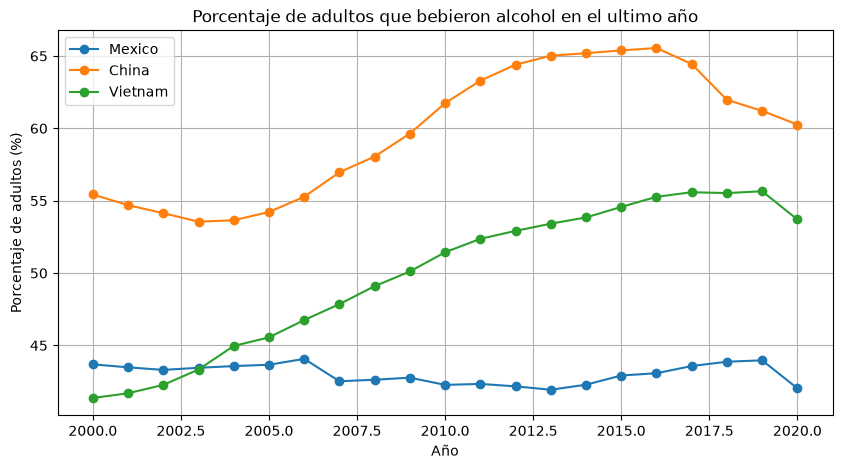

In [17]:
# Pregunta 8
mexico = df_paises[df_paises["entity"] == "Mexico"]
china = df_paises[df_paises["entity"] == "China"]
vietnam = df_paises[df_paises["entity"] == "Vietnam"]

plt.figure(figsize=(10, 5))

plt.plot(mexico["year"], mexico["valor"], label="Mexico", marker="o")
plt.plot(china["year"], china["valor"], label="China", marker="o")
plt.plot(vietnam["year"], vietnam["valor"], label="Vietnam", marker="o")

plt.title("Porcentaje de adultos que bebieron alcohol en el ultimo año")
plt.xlabel("Año")
plt.ylabel("Porcentaje de adultos (%)")
plt.legend()
plt.grid(True)
plt.show()


**Interpretación:**

La línea de **México** es casi plana, siempre entre 42% y 44%. **Vietnam** es el que más cambia:
en 2000 estaba debajo de México (41.4%) y subió sin parar hasta 55.7% en 2019, así que lo
rebasó. **China** siempre está arriba de los otros dos; sube mucho entre 2003 y 2016 y luego baja.
En 2020 los tres bajan, lo que coincide con la pandemia.

### Pregunta 9 — Visualización integradora

Crea dos gráficas de barras (horizontales o verticales) con el Top 10 de países según tu indicador en la primera consulta el año de tu nacimiento, y en la segunda el año 2023, ordenados de mayor a menor.  Qué movimientos hubo en ambas gráficas?
Agrega título y etiquetas de ejes.

No hay datos de 2023 - se usa el año mas reciente: 2020


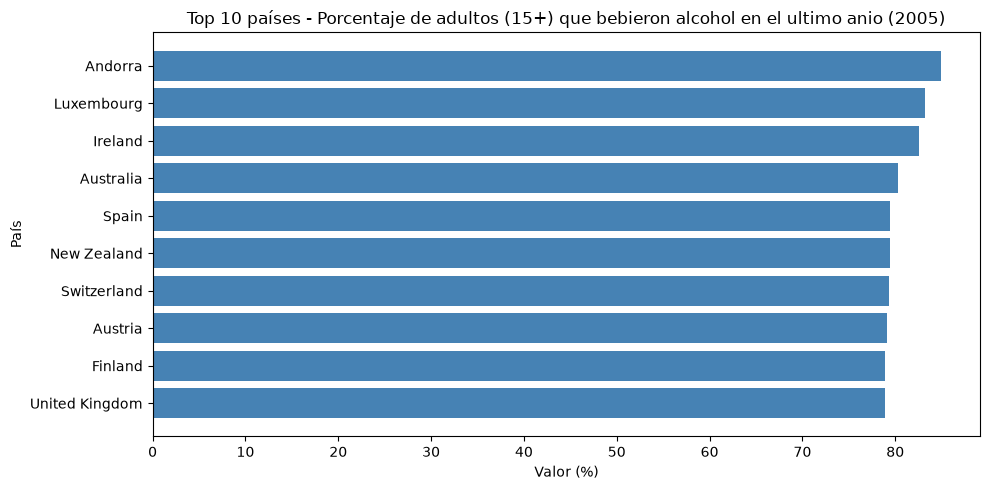

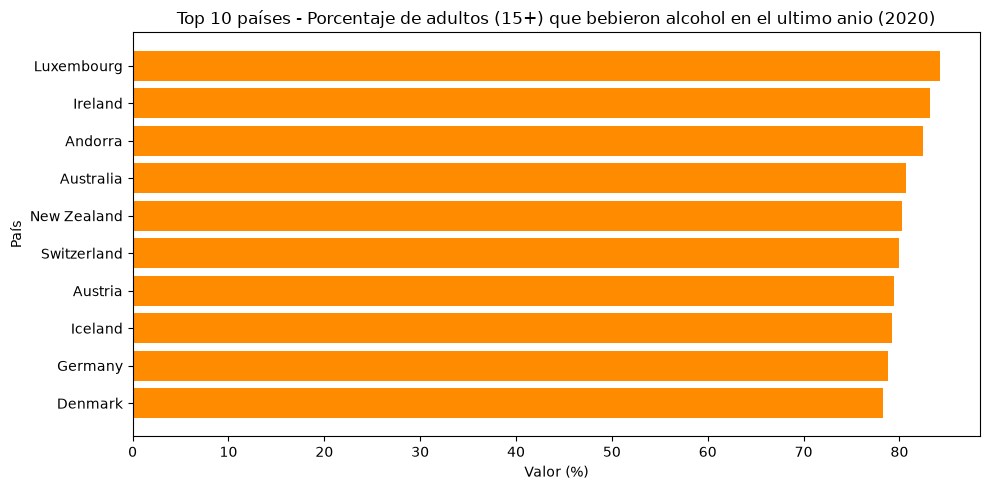

Salieron del top 10: ['Spain', 'Finland', 'United Kingdom']
Entraron al top 10: ['Iceland', 'Germany', 'Denmark']


In [18]:
# Pregunta 9
df_paises = df[df[config["filtro_paises"]].notnull()]

ANIO_NACIMIENTO = 2005   # <-- CAMBIA POR TU AÑO DE NACIMIENTO

# El dataset solo llega a 2020, no existe 2023.
# Si el año no existe uso el año mas reciente que haya.
anio_2 = 2023
if anio_2 not in df_paises["year"].values:
    print("No hay datos de", anio_2, "- se usa el año mas reciente:", df_paises["year"].max())
    anio_2 = df_paises["year"].max()

# ---- Grafica 1: año de nacimiento ----
top_nacimiento = (
    df_paises[df_paises["year"] == ANIO_NACIMIENTO]
    .sort_values("valor", ascending=False)
    .head(10)
)

plt.figure(figsize=(10, 5))
plt.barh(top_nacimiento["entity"], top_nacimiento["valor"], color="steelblue")
plt.xlabel(f"Valor ({config['unidad']})")
plt.ylabel("País")
plt.title(f"Top 10 países - {config['descripcion']} ({ANIO_NACIMIENTO})")
plt.gca().invert_yaxis()  # para que el pais con el valor mas alto quede arriba
plt.tight_layout()
plt.show()

# ---- Grafica 2: año 2023 (o el mas reciente) ----
top_reciente = (
    df_paises[df_paises["year"] == anio_2]
    .sort_values("valor", ascending=False)
    .head(10)
)

plt.figure(figsize=(10, 5))
plt.barh(top_reciente["entity"], top_reciente["valor"], color="darkorange")
plt.xlabel(f"Valor ({config['unidad']})")
plt.ylabel("País")
plt.title(f"Top 10 países - {config['descripcion']} ({anio_2})")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# Paises que entraron y salieron del top 10
lista_1 = top_nacimiento["entity"].tolist()
lista_2 = top_reciente["entity"].tolist()

print("Salieron del top 10:", [p for p in lista_1 if p not in lista_2])
print("Entraron al top 10:", [p for p in lista_2 if p not in lista_1])


**Interpretación:**

El dataset solo llega a **2020**, así que la segunda gráfica usa 2020 en lugar de 2023. Comparando
2005 con 2020, el top 10 sigue formado casi solo por países europeos más Australia y Nueva
Zelanda. Los movimientos:

- **Luxemburgo** sube del 2.º al 1.er lugar, **Irlanda** del 3.º al 2.º y **Andorra** baja del 1.º al 3.º.
- **Australia** se queda en 4.º. **Nueva Zelanda**, **Suiza** y **Austria** suben un lugar cada uno.
- **Salen** del top 10 España, Finlandia y Reino Unido.
- **Entran** Islandia, Alemania y Dinamarca.

Los valores casi no cambian (todos entre 78% y 85%), así que los cambios de lugar son por
diferencias pequeñas.

## 5. Conclusión general

En 5 - 10 líneas, resume qué aprendiste sobre el dataset que te tocó trabajar: ¿qué
patrones encontraste?, ¿qué limitaciones tiene la información (por ejemplo, valores
absolutos sin normalizar por población, datos faltantes, etc.)?, ¿qué harías distinto si
tuvieras más tiempo?

El dataset muestra el porcentaje de adultos que tomaron alcohol en el último año en 189 países,
del 2000 al 2020. El patrón más claro es que depende mucho de la **región y la cultura**:
Europa, Australia y Nueva Zelanda tienen más de 78%, y los países de Medio Oriente y el norte de
África tienen menos de 2%. La mayoría de los países cambian poco con los años (como México, casi
plano), pero algunos sí cambiaron mucho, como Vietnam y China. En 2020 casi todos bajan,
probablemente por la pandemia.

**Limitaciones:** los datos llegan solo a 2020 (no pude usar 2023), y muchos valores son
**estimaciones** con edad estandarizada, no encuestas de cada año. Además, el dato solo dice si
una persona tomó alcohol, no **cuánto** tomó. Una ventaja es que ya viene en porcentaje, así que
no hay que normalizar por población.

**Si tuviera más tiempo**, lo compararía con otro dataset de litros de alcohol per cápita o de
muertes por alcohol, separaría los datos por hombres y mujeres, y haría promedios por continente.

## 6. Entrega

1. Verifica que el notebook corra completo de arriba hacia abajo sin errores (`Kernel > Restart & Run All`).
2. Guarda el archivo con el nombre: `apellido_nombre_examen_parcial1.ipynb`.
3. Súbelo al repositorio de GitHub del curso, en una carpeta para este examen.
4. Comparte el link de tu repo y envia una copia del notebook por teams.
